In [1]:
import pynbody
import matplotlib.pylab as plt
import numpy as np
import pynbody.plot.sph as sph
from pynbody.analysis import profile
import pandas as pd
import cmasher as cmr




Elena = "/home/vadilloj/MAP2023/Sims/h329.cosmo50PLK.3072g/h329.cosmo50PLK.3072gst5HbwK1BH/h329.cosmo50PLK.3072gst5HbwK1BH.004096/ahf_200/h329.cosmo50PLK.3072gst5HbwK1BH.004096"

Sandra = "/home/vadilloj/MAP2023/Sims/h148.cosmo50PLK.3072g/h148.cosmo50PLK.3072g3HbwK1BH/snapshots_200crit_h148/h148.cosmo50PLK.3072g3HbwK1BH.004096"


Sandra_h="/home/vadilloj/MAP2023/Sims/h148.cosmo50PLK.6144g/h148.cosmo50PLK.6144g3HbwK1BH/h148.cosmo50PLK.6144g3HbwK1BH.004096/ahf_200/h148.cosmo50PLK.6144g3HbwK1BH.004096"
Elena_h ="/home/vadilloj/MAP2023/Sims/h329.cosmo50PLK.6144g/h329.cosmo50PLK.6144g5HbwK1BH/h329.cosmo50PLK.6144g5HbwK1BH.004096/ahf_200/h329.cosmo50PLK.6144g5HbwK1BH.004096"
# "home/christenc/Storage/Cosmo/h329.cosmo50PLK.6144g/h329.cosmo50PLK.6144g5HbwK1BH/h329.cosmo50PLK.6144g5HbwK1BH.004096/ahf_200/"



filepaths= ( Sandra_h, Elena_h, Elena, Sandra)
filenames=("Sandra_h", "Elena_h","Elena","Sandra",)

In [2]:
import sys
sys.path.append('/home/vadilloj/MAP2023/Vadillo-Justice-League-Code')
from Runnable_Modules import Base as base, IonUtils as ions, TrackingUtils as tracking
simulations  = base.get_chars("sims")##import modules previously run

In [3]:
pynbody.__version__


'2.4.1'

In [8]:
filepaths[0]

'/home/vadilloj/MAP2023/Sims/h148.cosmo50PLK.6144g/h148.cosmo50PLK.6144g3HbwK1BH/h148.cosmo50PLK.6144g3HbwK1BH.004096/ahf_200/h148.cosmo50PLK.6144g3HbwK1BH.004096'

In [11]:
s = pynbody.load(filepaths[1])

In [14]:
h = s.halos()

In [15]:
h[1]

<Halo "/home/vadilloj/MAP2023/Sims/h329.cosmo50PLK.6144g/h329.cosmo50PLK.6144g5HbwK1BH/h329.cosmo50PLK.6144g5HbwK1BH.004096/ahf_200/h329.cosmo50PLK.6144g5HbwK1BH.004096:halo_1" len=168970843>

In [12]:
s.g['mass']

SimArray([2.08038651e-13, 2.08038651e-13, 2.08038651e-13, ...,
          2.08038651e-13, 2.08038651e-13, 2.08038651e-13],
         shape=(24864642,), '1.59e+16 Msol')

In [57]:
h1s = np.empty(4, dtype = object)
profiles = np.empty(4, dtype = object)
for n in range(4):
    s = pynbody.load(filepaths[n])
    s.physical_units()

    h = s.halos(halo_numbers='v1')
    s.physical_units()

    
    pynbody.analysis.halo.center(h[1]) # recenters
    cen = pynbody.analysis.halo.center(h[1], return_cen = True) # recenters
    rvir = np.max(h[1]['r'])
    
    h1Filter = pynbody.filt.Sphere(rvir, cen)
    print(rvir)
    
    
    h1 = s[h1Filter]
    ions.calculate_gas_mass(s)
    ions.calculate_gas_rhos(s)

    pynbody.analysis.angmom.sideon(h1.g)
    h1s[n] = h1
    profiles[n] = profile.Profile(h1.g, rmin =.01, rmax=np.max(h1.g['r']))
    


pynbody.halo : Unable to load AHF substructure file; continuing without. To expose the underlying problem as an exception, pass ignore_missing_substructure=False to the AHFCatalogue constructor


267.5904697593163


/home/vadilloj/anaconda3/envs/conda-env-py311/lib/python3.11/site-packages/pynbody/analysis/halo.py:100: RuntimeWarning: Final sphere is empty; cannot return a velocity. This probably implies something is wrong with the position centre too.
  warnings.warn("Final sphere is empty; cannot return a velocity. This probably implies something is "


OverflowError: Python integer -1 out of bounds for uint64

In [35]:
profiles[0].derivable_keys() 

['weight_fn',
 'mass',
 'density',
 'fourier',
 'pattern_frequency',
 'mass_enc',
 'density_enc',
 'dyntime',
 'g_spherical',
 'rotation_curve_spherical',
 'j_circ',
 'v_circ',
 'v_circ_total',
 'E_circ',
 'pot',
 'omega',
 'kappa',
 'beta',
 'magnitudes',
 'sb',
 'Q',
 'X',
 'jtot',
 'j_theta',
 'j_phi']

In [ ]:
# make the plot
fig, axs = plt.subplots(3, figsize=(8, 12), sharex = True)
for n in range(4):
    prof = profiles[n]
    name = filenames[n]
    axs[0].plot(prof['rbins'],prof['density'], label = name)
    axs[0].set_ylabel('all')
    axs[1].plot(prof['rbins'],prof['HI_rho'], label = name)
    axs[1].set_ylabel('HI')
    axs[2].plot(prof['rbins'],prof['OVI_rho'], label = name)
    axs[2].set_ylabel('OVI')
axs[.legend()
axs[0].semilogy()
axs[1].semilogy()
axs[2].semilogy()
plt.xlabel('R [kpc]')

fig.supylabel(r'$\Sigma_{\star}$ [M$_{\odot}$ kpc$^{-2}$]')
fig.suptitle('Density vs R Profiles')





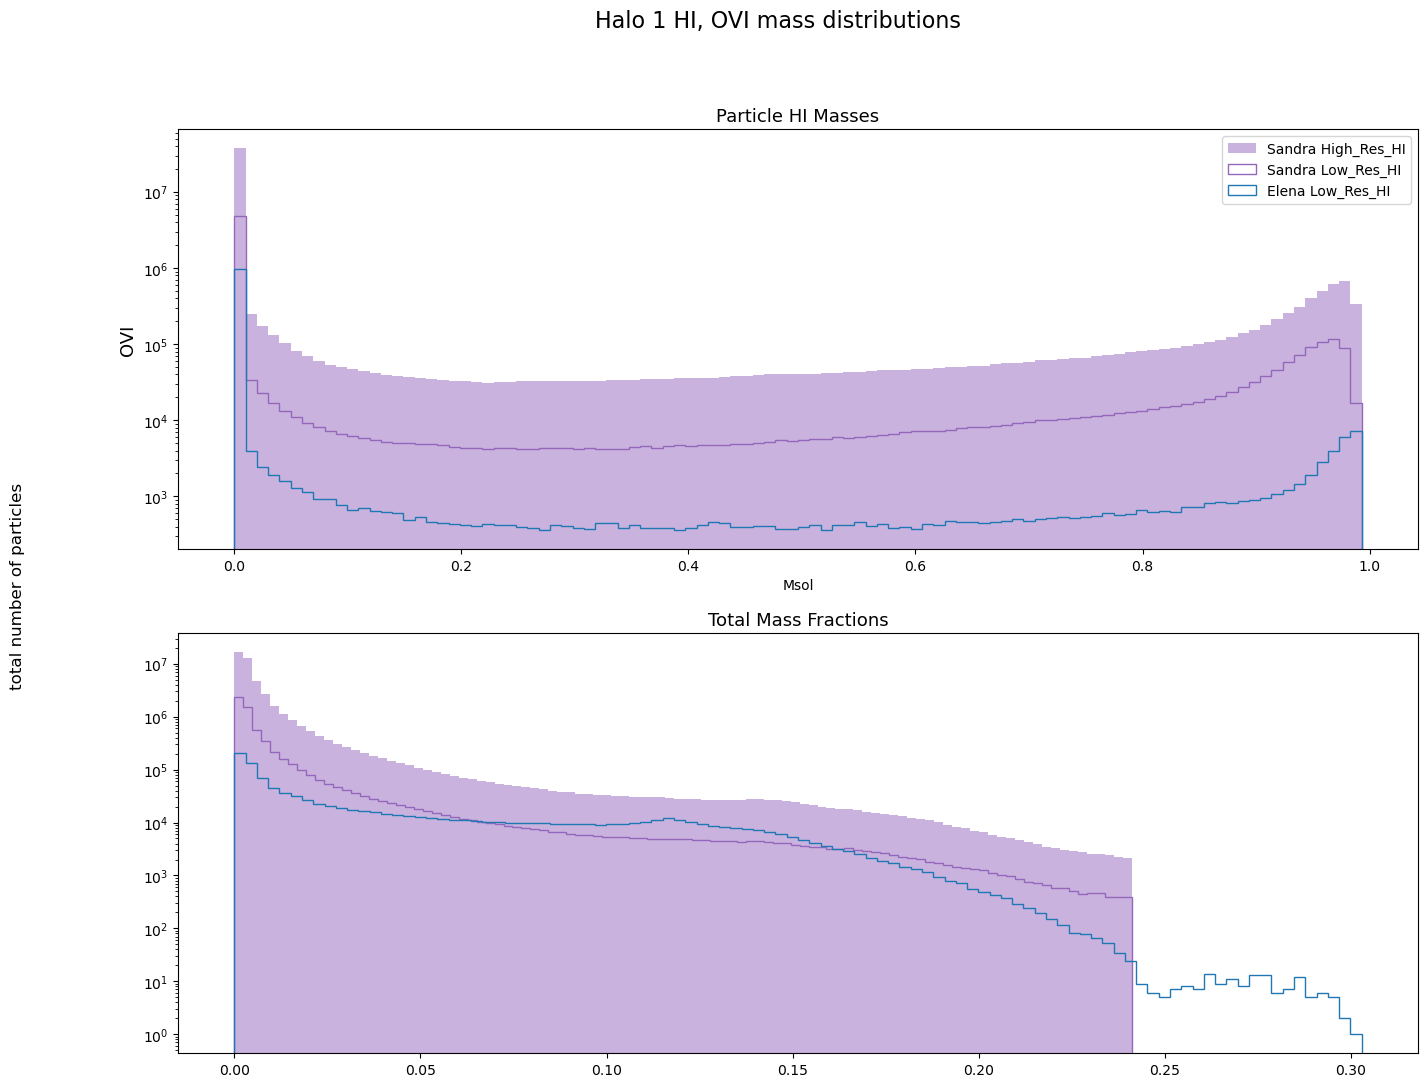

In [55]:

fig, axs = plt.subplots(2, 1, figsize=(16, 12))# define plot

axs[0].hist(h1s[0].g["hiif"],bins = 100, log = True, color = "tab:Purple", alpha = 0.5, label = "Sandra High_Res_HI")# create H1 mass plot, define column and row tittle
axs[0].hist(h1s[2].g["hiif"],bins = 100, log = True, histtype = 'step' , color = "tab:Purple", label = "Sandra Low_Res_HI")# create H1 mass plot, define column and row tittle
axs[0].hist(h1s[1].g["hiif"],bins = 100, log = True, histtype = 'step' , color = "tab:blue", label = "Elena Low_Res_HI")# create H1 mass frac plot, define column tittle

axs[1].hist(h1s[0].g["oviif"],bins = 100, log = True, color = "tab:Purple", alpha = 0.5, label = "Sandra High_Res_OVI")# create H1 mass plot, define column and row tittle
axs[1].hist(h1s[2].g["oviif"],bins = 100, histtype = 'step' , log = True, color = "tab:Purple", label = "Sandra Low_Res_OVI")# create H1 mass plot, define column and row tittle
axs[1].hist(h1s[1].g["oviif"],bins = 100, histtype = 'step' , log = True, color = "tab:blue", label = "Elena Low_Res_OVI")# create H1 mass frac plot, define column tittle

# # with ionf.use_custom_ion_table('v1_duffy'):
# #     h1.gas['hiif'] = pynbody.analysis.ionfrac.calculate(h1.gas,ion='hi')
# #     plot_HI_and_OVI('c','r', 'v1_shielded')
# h1.gas['hiif'] = pynbody.analysis.ionfrac.calculate(h1.gas,ion='hi')
# h1.gas['oviif'] = pynbody.analysis.ionfrac.calculate(h1.gas,ion='ovi')


axs[0].set_xlabel("Total particles")
axs[0].set_title('Particle HI Masses',fontsize = 13)
axs[0].set_ylabel('HI',fontsize = 13)
axs[1].set_title('Total Mass Fractions',fontsize = 13)


axs[0].legend()
axs[0].legend()
axs[0].set_xlabel("Msol")
axs[0].set_ylabel('OVI',fontsize = 13)

fig.supylabel('total number of particles')



fig.suptitle('Halo 1 HI, OVI mass distributions', fontsize = 16) # add tittle
plt.savefig("HI and OVI HI particle mass")

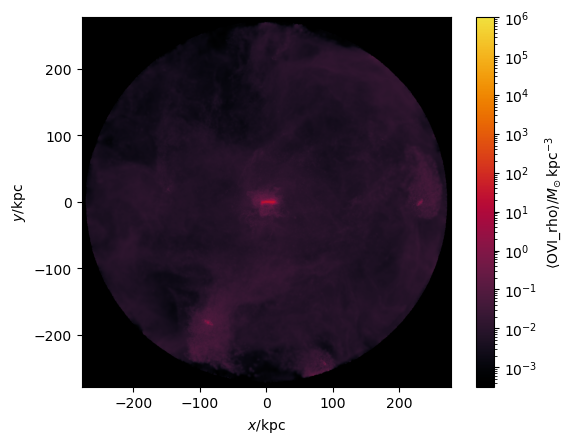

In [50]:
edge = 278
fig, ax = plt.subplots()
vmin = 10**-3.5
vmax = 10** 6
sph.image(h1s[0].g, 'OVI_rho', width = 2*edge,axes = ax, weight = True, cmap = 'cmr.ember',vmin = vmin, vmax = vmax)

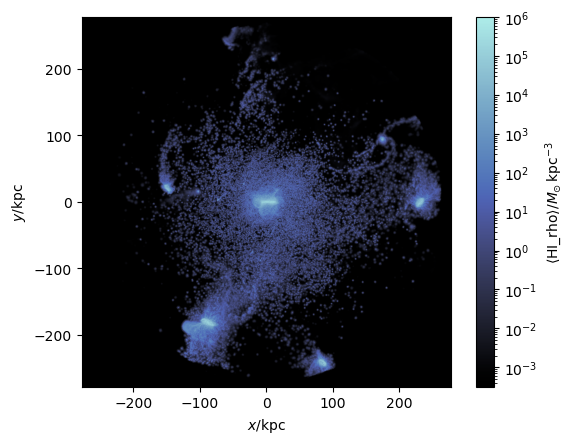

In [51]:
fig, ax = plt.subplots()
vmin = 10**-3.5
vmax = 10** 6
sph.image(h1s[0].g, 'HI_rho',  axes = ax, width = 2*edge, weight = True, cmap = 'cmr.sapphire' ,vmin = vmin, vmax = vmax)